In [1]:
# run pip install "gymnasium[classic-control]

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import utils
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box, Discrete

import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common import results_plotter
from stable_baselines3.common.results_plotter import load_results, ts2xy, plot_results
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env

In [3]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced
class ROVEnv(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rov.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

    def step(self, action):        
        xy_position_before = self.data.qpos[0:2].copy()
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after, action)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.5:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position, action):
        distance_from_goal = self.goal_position - position
        distance_reward = self.distance_reward_weight * np.exp(-np.linalg.norm(distance_from_goal)**2)
        total_reward = distance_reward

        reward = total_reward

        reward_info = {
            "distance_reward": distance_reward,
            "total_reward": total_reward,
        }

        return reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.goal_position = self.np_random.uniform(low=-4.8, high=4.8, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [4]:
# https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html
# https://stable-baselines3.readthedocs.io/en/master/guide/examples.html
# https://medium.com/@itsrarjun/mastering-reinforcement-learning-ppo-in-mujoco-for-robotics-simulation-e320349ee7f9

# Create log dir
log_dir = "tmp/"
os.makedirs(log_dir, exist_ok=True)

env = ROVEnv(xml_file="/home/charstieve/cs4180/rov.xml")
check_env(env)
env = Monitor(env, log_dir)

model = PPO("MlpPolicy", env, verbose=1)

model.learn(total_timesteps=1000000)
model.save("ppo_rov")

del model # remove to demonstrate saving and loading

model = PPO.load("ppo_rov")

[3.0073943  3.96245354]
[ 3.03219412 -4.7737104 ]
[3.48651765 0.39802771]
Using cpu device
Wrapping the env in a DummyVecEnv.


/home/charstieve/cs4180/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


[1.63799438 1.41301931]
[1.78120305 1.44440905]
[ 0.2434015  -1.82167799]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 7.69     |
| time/              |          |
|    fps             | 4488     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
[ 0.68668638 -1.71005385]
[-2.6192871   1.18259659]
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | 18.8         |
| time/                   |              |
|    fps                  | 1251         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0047566565 |
|    clip_fraction        | 0.0417       |
|    clip_range   

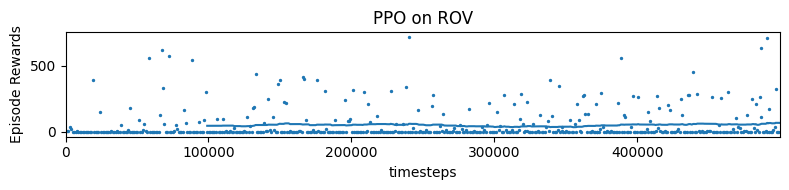

In [5]:
plot_results([log_dir], 500000, results_plotter.X_TIMESTEPS, "PPO on ROV")
plt.show()

In [6]:
view_env = ROVEnv(xml_file="/home/charstieve/cs4180/rov.xml", render_mode="human")

obs, info = view_env.reset()
counter = 0
while counter <= 3:
    action, _states = model.predict(obs)
    obs, rewards, terminated, truncated, info = view_env.step(action)

    if terminated or truncated:
        print("BEFORE RESET: \n", info)
        obs, info = view_env.reset()
        counter += 1

[ 4.24591341 -1.36573071]
BEFORE RESET: 
 {'x_position': np.float64(2.4208837395610887), 'y_position': np.float64(0.06021274009989126), 'distance_from_origin': np.float64(2.421632435887333), 'x_velocity': np.float64(0.25819477105371025), 'y_velocity': np.float64(-0.04387601562840914), 'distance_reward': np.float64(0.004681915317737005), 'total_reward': np.float64(0.004681915317737005)}
[-4.45650615 -4.05355876]
BEFORE RESET: 
 {'x_position': np.float64(-1.9890374787426623), 'y_position': np.float64(-0.9999326042200877), 'distance_from_origin': np.float64(2.2262379263738485), 'x_velocity': np.float64(-0.25995111266216564), 'y_velocity': np.float64(-0.12345663044670274), 'distance_reward': np.float64(2.0239707193203313e-07), 'total_reward': np.float64(2.0239707193203313e-07)}
[ 4.02361163 -4.30958684]
BEFORE RESET: 
 {'x_position': np.float64(1.6037619770890004), 'y_position': np.float64(-0.8901311945957574), 'distance_from_origin': np.float64(1.8342262735957333), 'x_velocity': np.float6

The render above showed the ROV was barely moving, which explains the lack of training. To attempt to combat this we are going to change the environment space in a few ways...
- Discrete Action Space
- Closer goals
- Parallel Training
- Fix NAN errors from drag coefficient

In [2]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced
class ROVEnv_v0(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rov.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

        self.possible_actions = {
            0: np.array([ 0,  0,  0,  0]), # stop
            1: np.array([-1,  1,  1, -1]), # left
            2: np.array([ 1, -1, -1,  1]), # right
            3: np.array([ 1,  1, 1, 1]), # forward
            4: np.array([-1, -1,  -1,  -1]), # backward
            5: np.array([ 1,  0,  0,  1]), # diagonal right forward
            6: np.array([ -1,  0,  0,  -1]), # diagonal left backward
            7: np.array([0, 1,  1,  0]), # diagonal left forward
            8: np.array([ 0,  -1,  -1,  0]), # diagonal right backward
        }

        self.action_space = Discrete(len(self.possible_actions))

        
    def step(self, action):        
        xy_position_before = self.data.qpos[0:2].copy()
        action = self.possible_actions[int(action)]
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.5:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position):
        distance_from_goal = self.goal_position - position
        distance_reward = self.distance_reward_weight * np.exp(-np.linalg.norm(distance_from_goal)**2)
        total_reward = distance_reward

        reward = total_reward

        reward_info = {
            "distance_reward": distance_reward,
            "total_reward": total_reward,
        }

        return reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.goal_position = self.np_random.uniform(low=-2, high=2, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [3]:
# https://stackoverflow.com/questions/73694119/how-to-register-custom-environment-with-openais-gym-package-to-use-make-vec-env
myEnv_id = 'cs4180/ROVEnv_v0'

gym.envs.registration.register(
    id=myEnv_id,
    entry_point=ROVEnv_v0,
    max_episode_steps=1000,
)

In [4]:
# https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html
# https://stable-baselines3.readthedocs.io/en/master/guide/examples.html
# https://medium.com/@itsrarjun/mastering-reinforcement-learning-ppo-in-mujoco-for-robotics-simulation-e320349ee7f9

# Create log dir
log_dir = "tmp_v0/"
os.makedirs(log_dir, exist_ok=True)

env = make_vec_env(myEnv_id, 
                   n_envs=8, 
                   seed=0, 
                   env_kwargs={"xml_file": "/home/charstieve/cs4180/rov.xml"}, 
                   monitor_dir=log_dir)

model = PPO("MlpPolicy", env, verbose=1)

model.learn(total_timesteps=1000000)
model.save("ppo_rov_v0")

del model # remove to demonstrate saving and loading

model = PPO.load("ppo_rov_v0")

/home/charstieve/cs4180/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Using cpu device
[1.25308096 1.65102231]
[-0.75267419 -0.3066942 ]
[0.4004021  0.91424211]
[-1.62348543 -0.26749224]
[ 0.42942333 -0.49405366]
[-1.78427719 -0.46652448]
[1.94977996 0.53102509]
[-0.79933486  1.49421378]
[ 1.26341422 -1.989046  ]
[1.01405243 0.15257325]
[ 0.24906265 -1.39975095]
[-0.43508724  0.06696073]
[ 1.60886032 -0.0913859 ]
[ 0.60947645 -1.06195919]
[-1.79308307  1.40076539]
[-0.78787029 -0.88629755]
[-0.86319535  0.59418883]
[1.45271569 0.16584488]
[-1.46383321 -0.38754805]
[1.86974381 0.73225929]
[1.87573148 1.71610555]
[-0.43038134 -0.02790793]
[-1.80766605 -1.17024294]
[1.98200113 1.17064768]
[-0.80639511 -0.74405599]
[ 1.51860469 -1.74314225]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 889      |
|    ep_rew_mean     | 173      |
| time/              |          |
|    fps             | 7419     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 16384    |
-----------------

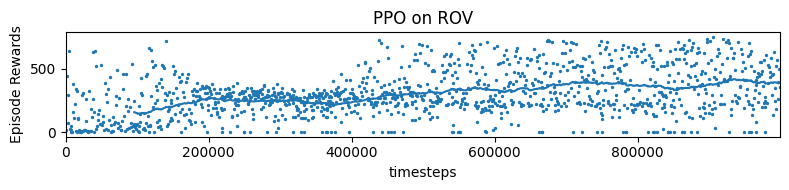

In [5]:
plot_results([log_dir], 1000000, results_plotter.X_TIMESTEPS, "PPO on ROV")
plt.show()

In [6]:
view_env = ROVEnv_v0(xml_file="/home/charstieve/cs4180/rov.xml", render_mode="human")

obs, info = view_env.reset()
counter = 0
while counter <= 3:
    action, _states = model.predict(obs)
    obs, rewards, terminated, truncated, info = view_env.step(action)

    if terminated or truncated:
        print("BEFORE RESET: \n", info)
        obs, info = view_env.reset()
        counter += 1

[-1.0690351   1.01025407]
BEFORE RESET: 
 {'x_position': np.float64(-0.5907915945756007), 'y_position': np.float64(0.683300563655982), 'distance_from_origin': np.float64(0.9032908548821712), 'x_velocity': np.float64(0.019400525038640315), 'y_velocity': np.float64(0.08522463207952247), 'distance_reward': np.float64(0.7148979689497271), 'total_reward': np.float64(0.7148979689497271)}
[-0.15000838  0.11760046]
BEFORE RESET: 
 {'x_position': np.float64(-0.08147651360499329), 'y_position': np.float64(-0.08347096772190529), 'distance_from_origin': np.float64(0.11664400851160771), 'x_velocity': np.float64(0.08249713495389784), 'y_velocity': np.float64(-0.02118003669854089), 'distance_reward': np.float64(0.9558767106329692), 'total_reward': np.float64(0.9558767106329692)}
[-0.09270613  1.22545659]
BEFORE RESET: 
 {'x_position': np.float64(0.3189197391456043), 'y_position': np.float64(0.8376682897462692), 'distance_from_origin': np.float64(0.8963246976755354), 'x_velocity': np.float64(0.0764884

In [11]:
import pandas as pd

df = load_results("/home/charstieve/cs4180/tmp_v0")
print(df.describe())

             index            r            l            t
count  1291.000000  1291.000000  1291.000000  1291.000000
mean     80.202943   306.360145   783.929512   353.576123
std      46.628989   183.073525   308.075721   217.483187
min       0.000000     0.783233     1.000000     1.865905
25%      40.000000   196.349133   632.500000   166.545654
50%      80.000000   280.270800  1000.000000   340.411015
75%     120.500000   415.487126  1000.000000   554.449170
max     165.000000   752.632347  1000.000000   716.625310


This looks a lot better, but there is still a lot of variance in the rewards...
- Add a penalty to encourage efficiency

In [18]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced
class ROVEnv_v2(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rov.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

        self.possible_actions = {
            0: np.array([ 0,  0,  0,  0]), # stop
            1: np.array([-1,  1,  1, -1]), # left
            2: np.array([ 1, -1, -1,  1]), # right
            3: np.array([ 1,  1, 1, 1]), # forward
            4: np.array([-1, -1,  -1,  -1]), # backward
            5: np.array([ 1,  0,  0,  1]), # diagonal right forward
            6: np.array([ -1,  0,  0,  -1]), # diagonal left backward
            7: np.array([0, 1,  1,  0]), # diagonal left forward
            8: np.array([ 0,  -1,  -1,  0]), # diagonal right backward
        }

        self.action_space = Discrete(len(self.possible_actions))

        
    def step(self, action):        
        xy_position_before = self.data.qpos[0:2].copy()
        action = self.possible_actions[int(action)]
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "distance_to_goal": np.linalg.norm(observation[0:2]),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.5:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position):
        distance_from_goal = self.goal_position - position
        distance_reward = self.distance_reward_weight * np.exp(-np.linalg.norm(distance_from_goal)**2)

        penalty = -0.1
        
        total_reward = distance_reward + penalty

        reward = total_reward

        reward_info = {
            "distance_reward": distance_reward,
            "total_reward": total_reward,
        }

        return reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.goal_position = self.np_random.uniform(low=-2, high=2, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [19]:
# https://stackoverflow.com/questions/73694119/how-to-register-custom-environment-with-openais-gym-package-to-use-make-vec-env
myEnv_id = 'cs4180/ROVEnv_v2'

gym.envs.registration.register(
    id=myEnv_id,
    entry_point=ROVEnv_v2,
    max_episode_steps=1000,
)

In [20]:
# https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html
# https://stable-baselines3.readthedocs.io/en/master/guide/examples.html
# https://medium.com/@itsrarjun/mastering-reinforcement-learning-ppo-in-mujoco-for-robotics-simulation-e320349ee7f9

# Create log dir
# Change from v2 -> v3 was logging distance to goal
log_dir = "tmp_v3/"
os.makedirs(log_dir, exist_ok=True)

env = make_vec_env(myEnv_id, 
                   n_envs=8, 
                   seed=0, 
                   env_kwargs={"xml_file": "/home/charstieve/cs4180/rov.xml"}, 
                   monitor_dir=log_dir,
                   monitor_kwargs={"info_keywords": ("distance_to_goal",)})

model = PPO("MlpPolicy", env, verbose=1)

model.learn(total_timesteps=1000000)
model.save("ppo_rov_v3")

del model # remove to demonstrate saving and loading

model = PPO.load("ppo_rov_v3", env=env)

/home/charstieve/cs4180/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Using cpu device
[1.25308096 1.65102231]
[-0.75267419 -0.3066942 ]
[0.4004021  0.91424211]
[-1.62348543 -0.26749224]
[ 0.42942333 -0.49405366]
[-1.78427719 -0.46652448]
[1.94977996 0.53102509]
[-0.79933486  1.49421378]
[ 1.26341422 -1.989046  ]
[1.01405243 0.15257325]
[ 0.24906265 -1.39975095]
[-0.43508724  0.06696073]
[ 1.60886032 -0.0913859 ]
[ 0.60947645 -1.06195919]
[-1.79308307  1.40076539]
[-0.78787029 -0.88629755]
[-0.86319535  0.59418883]
[1.45271569 0.16584488]
[-1.46383321 -0.38754805]
[1.86974381 0.73225929]
[1.87573148 1.71610555]
[-0.43038134 -0.02790793]
[-1.80766605 -1.17024294]
[1.98200113 1.17064768]
[-0.80639511 -0.74405599]
[ 1.51860469 -1.74314225]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 889      |
|    ep_rew_mean     | 77.5     |
| time/              |          |
|    fps             | 4981     |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 16384    |
-----------------

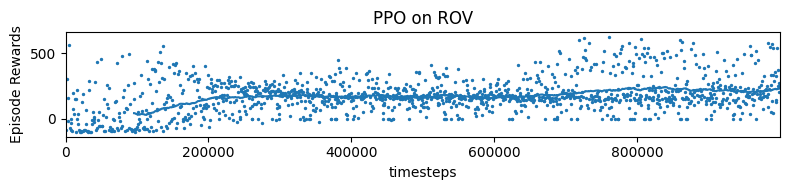

In [21]:
plot_results([log_dir], 1000000, results_plotter.X_TIMESTEPS, "PPO on ROV")
plt.show()

In [22]:
view_env = ROVEnv_v2(xml_file="/home/charstieve/cs4180/rov.xml", render_mode="human")

obs, info = view_env.reset()
counter = 0
while counter <= 3:
    action, _states = model.predict(obs)
    obs, rewards, terminated, truncated, info = view_env.step(action)

    if terminated or truncated:
        print("BEFORE RESET: \n", info)
        obs, info = view_env.reset()
        counter += 1

[ 1.97679964 -1.25073402]
BEFORE RESET: 
 {'x_position': np.float64(1.6925454586570552), 'y_position': np.float64(-0.8196510189276606), 'distance_from_origin': np.float64(1.8805685104376744), 'distance_to_goal': np.float64(0.5163651763909712), 'x_velocity': np.float64(0.08390409714384428), 'y_velocity': np.float64(-0.08351634909020689), 'distance_reward': np.float64(0.7659541285843814), 'total_reward': np.float64(0.6659541285843814)}
[-0.50809708 -0.78165384]
BEFORE RESET: 
 {'x_position': np.float64(-0.17059871491121098), 'y_position': np.float64(-0.41532835660015577), 'distance_from_origin': np.float64(0.44900062953802505), 'distance_to_goal': np.float64(0.49809588465173943), 'x_velocity': np.float64(-0.13586366373319336), 'y_velocity': np.float64(-0.20459634616788042), 'distance_reward': np.float64(0.7802822932840605), 'total_reward': np.float64(0.6802822932840605)}
[0.57622033 1.23464781]
BEFORE RESET: 
 {'x_position': np.float64(0.5404757843531558), 'y_position': np.float64(0.7366

In [5]:
import pandas as pd

df = load_results("/home/charstieve/cs4180/tmp_v3")
print(df.describe())

             index            r            l            t  distance_to_goal
count  1404.000000  1404.000000  1404.000000  1404.000000       1404.000000
mean     87.299858   178.201828   721.508547   438.259760          0.644997
std      50.766897   130.873219   315.394648   235.769775          0.371296
min       0.000000   -99.285092     1.000000     3.064372          0.032334
25%      43.000000   114.323611   522.500000   244.694246          0.499288
50%      87.000000   169.407319   822.500000   443.934846          0.499810
75%     131.000000   231.233389  1000.000000   616.567247          0.597595
max     183.000000   624.059900  1000.000000   847.092379          2.893470


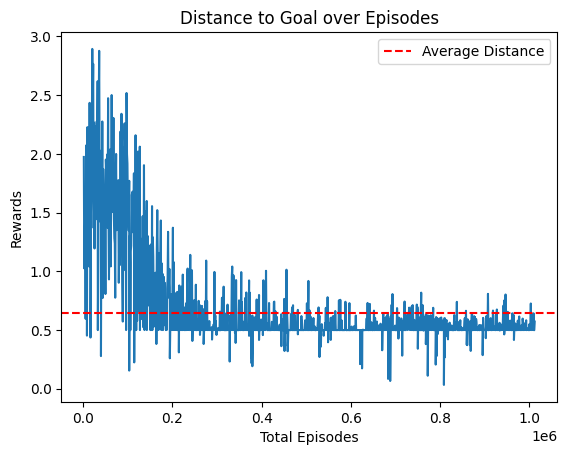

In [8]:
import matplotlib.pyplot as plt

average_distance = df['distance_to_goal'].mean()

# Plotting average sales
plt.plot(df['l'].cumsum(), df['distance_to_goal'])
plt.axhline(y=average_distance, color='r', linestyle='--', label='Average Distance')
plt.title('Distance to Goal over Episodes')
plt.xlabel('Total Episodes')
plt.ylabel('Rewards')
plt.legend()
plt.show()